# Week 06 - Deep Learning Models (LSTM)

In [1]:
import sys
sys.path.append('../src')
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from splits import load_splits, split_frame

SEED = 42
keras.utils.set_random_seed(SEED)


2026-08-11 12:50:39.092334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Loading the Same Split as the Tree Models

This notebook used to take the first 70 engine IDs in sorted order, while
notebook 03-04 shuffled them. A comment here claimed the two matched. They did
not, so engines held out from gradient boosting were sitting inside the LSTM's
training set and every "LSTM beats gradient boosting" claim was measured on
different data.

Both now read the same `splits.json` artifact, which makes the comparison at
the bottom of this notebook an actual comparison.


In [2]:
df = pd.read_csv('../data/gold/cmapss/FD001_top_features.csv')
splits = load_splits()

feature_cols = [c for c in df.columns
                if c not in ['engine_id', 'time_cycles', 'RUL', 'RUL_clipped']]

print(f"Data: {df.shape}")
print(f"Engines - train: {len(splits['train'])}, "
      f"val: {len(splits['val'])}, test: {len(splits['test'])}")
print(f"Using {len(feature_cols)} features")


Data: (20631, 24)
Engines - train: 70, val: 15, test: 15
Using 20 features


In [3]:
def create_sequences(frame, sequence_length=30, feature_cols=None):
    """Create sliding-window sequences for LSTM input.

    Windows are built one engine at a time, so no window spans the boundary
    between two engines.
    """
    sequences, targets, engine_ids = [], [], []

    for engine_id, engine in frame.groupby('engine_id', sort=True):
        engine = engine.sort_values('time_cycles')
        values = engine[feature_cols].to_numpy()
        rul = engine['RUL_clipped'].to_numpy()

        for i in range(len(engine) - sequence_length + 1):
            sequences.append(values[i:i + sequence_length])
            targets.append(rul[i + sequence_length - 1])   # RUL at end of window
            engine_ids.append(engine_id)

    return np.array(sequences), np.array(targets), np.array(engine_ids)


sequence_length = 30


In [4]:
# Split by engine first, then build sequences inside each split. In this order
# it is structurally impossible for a window to straddle the train/test line.
train_f, val_f, test_f = split_frame(df, splits)

X_train, y_train, _ = create_sequences(train_f, sequence_length, feature_cols)
X_val, y_val, _ = create_sequences(val_f, sequence_length, feature_cols)
X_test, y_test, _ = create_sequences(test_f, sequence_length, feature_cols)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print("Shape is (samples, timesteps, features)")
print(f"RUL range: {y_train.min():.0f} to {y_train.max():.0f} cycles")


Train: (12377, 30, 20)
Val:   (2725, 30, 20)
Test:  (2629, 30, 20)
Shape is (samples, timesteps, features)
RUL range: 0 to 125 cycles


## Scaling, and Actually Keeping the Scaler

The gold layer is already min-max normalised by the feature pipeline. The
`StandardScaler` below is a second, LSTM-specific step, fit on training
sequences only: centring the inputs makes the recurrent layer easier to train.

The earlier version fit this scaler and then saved only the Keras model. At
inference the dashboard had no scaler to load, so it fed the network min-max
data while the network had been trained on standardised data. The model was
being served inputs on a scale it had never seen, and nothing failed loudly
about it.

Saving the scaler next to the model is the fix. More generally, a model plus
its fitted transformers is the artifact, and a model on its own is not
servable.


In [5]:
n_features = len(feature_cols)

# Fit on training sequences only.
scaler = StandardScaler().fit(X_train.reshape(-1, n_features))


def scale(x):
    return scaler.transform(x.reshape(-1, n_features)).reshape(x.shape)


X_train_scaled = scale(X_train)
X_val_scaled = scale(X_val)
X_test_scaled = scale(X_test)

print("Features standardised")
print(f"Train - mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Val   - mean: {X_val_scaled.mean():.4f}, std: {X_val_scaled.std():.4f}")
print(f"Test  - mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")


Features standardised
Train - mean: 0.0000, std: 1.0000
Val   - mean: -0.0450, std: 1.0021
Test  - mean: 0.0002, std: 1.0206


In [6]:
def build_lstm_model(input_shape, lstm_units=32, dense_units=16,
                     lstm_dropout=0.3, dense_dropout=0.2, learning_rate=0.0005):
    """Build the LSTM.

    The arguments are used. The earlier version accepted `lstm_units` and
    `dropout` and then ignored both in favour of hardcoded values, which made
    the signature actively misleading to anyone trying to tune it.
    """
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units, return_sequences=False),
        Dropout(lstm_dropout),
        Dense(dense_units, activation='relu'),
        Dropout(dense_dropout),
        Dense(1),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae'],
    )
    return model


lstm_model = build_lstm_model((sequence_length, n_features))
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,329 (28.63 KB)

 Trainable params: 7,329 (28.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=10,
    min_lr=1e-6)

# Train
history = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

Epoch 1/150


 1/97 ━━━━━━━━━━━━━━━━━━━━ 3:45 2s/step - loss: 80.6509 - mae: 80.6509

 4/97 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 81.5629 - mae: 81.5629

 8/97 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 81.4716 - mae: 81.4716

12/97 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 81.0597 - mae: 81.0597

...

90/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 14.3737 - mae: 14.3737

93/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 14.3788 - mae: 14.3788

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 14.3840 - mae: 14.3840

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 14.5063 - mae: 14.5063 - val_loss: 13.1853 - val_mae: 13.1853 - learning_rate: 4.5000e-05



Training completed!


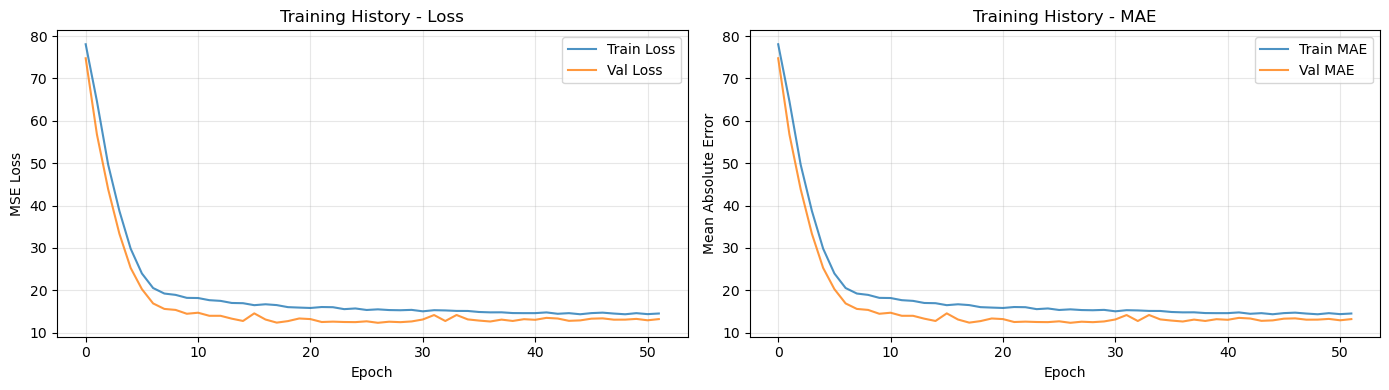

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', alpha=0.8)
ax1.plot(history.history['val_loss'], label='Val Loss', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training History - Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# MAE
ax2.plot(history.history['mae'], label='Train MAE', alpha=0.8)
ax2.plot(history.history['val_mae'], label='Val MAE', alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.set_title('Training History - MAE')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:<12} MAE: {mae:6.2f}   RMSE: {rmse:6.2f}   R2: {r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


y_val_pred = lstm_model.predict(X_val_scaled, verbose=0).flatten()
y_test_pred = lstm_model.predict(X_test_scaled, verbose=0).flatten()

print("LSTM PERFORMANCE")
val_res = evaluate(y_val, y_val_pred, "Validation")
test_res = evaluate(y_test, y_test_pred, "Test")


LSTM PERFORMANCE
Validation   MAE:  12.31   RMSE:  16.76   R2: 0.8397
Test         MAE:  12.29   RMSE:  16.51   R2: 0.8433


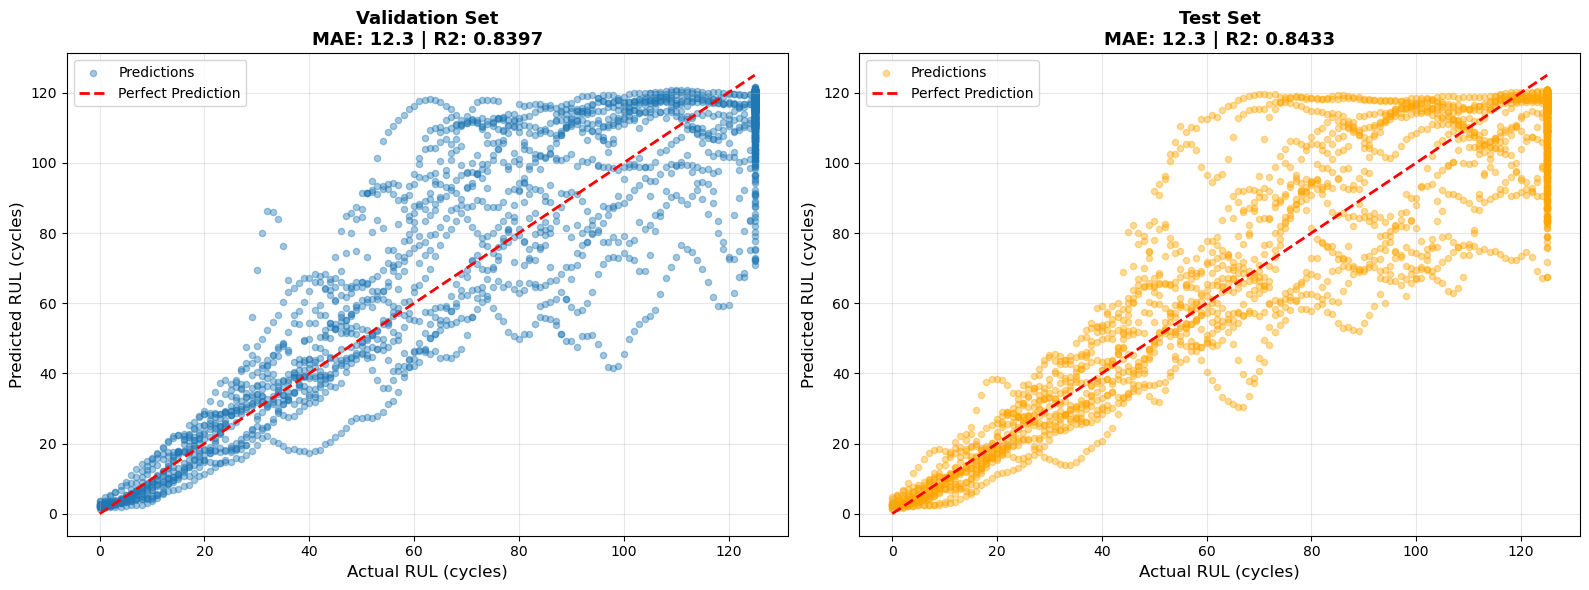

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(y_val, y_val_pred, alpha=0.4, s=20, label='Predictions')
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax1.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax1.set_title(f"Validation Set\nMAE: {val_res['mae']:.1f} | R2: {val_res['r2']:.4f}",
              fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.scatter(y_test, y_test_pred, alpha=0.4, s=20, label='Predictions', color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax2.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax2.set_title(f"Test Set\nMAE: {test_res['mae']:.1f} | R2: {test_res['r2']:.4f}",
              fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


ALL MODELS, SAME SPLIT, SAME PROTOCOL
            Model  Val R2  Test R2  Test MAE
  LSTM (this run)  0.8397   0.8433     12.29
Gradient Boosting  0.8289   0.8119     13.42
    Random Forest  0.8256   0.8027     14.22
Linear Regression  0.8085   0.7563     16.61
            Ridge  0.8099   0.7563     16.63
            Lasso  0.7941   0.7332     17.56


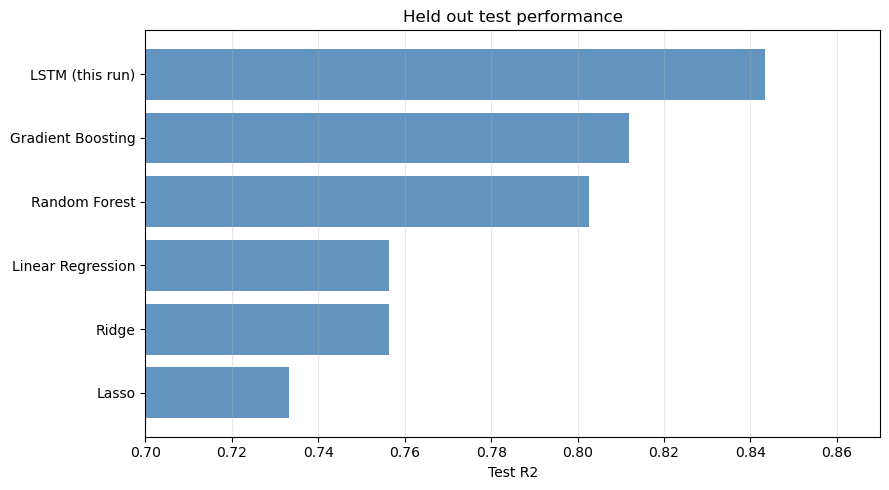

In [11]:
# Compare against the tree models. Their numbers come from the metrics artifact
# that src/train.py writes, so this cell cannot go stale the next time anything
# is retrained. The tree models are deterministic given the seed, so those rows
# are identical to what this notebook would produce.
#
# The LSTM row uses THIS run's numbers, not the artifact's. Mixing a stored LSTM
# score with a freshly trained one would be comparing across runs, which is the
# exact mistake this notebook exists to correct. See the note on reproducibility
# in the summary below.
with open('../data/models/cmapss/metrics.json') as f:
    metrics = json.load(f)

rows = []
for name, m in metrics['models'].items():
    if name == 'lstm':
        continue
    rows.append({
        'Model': name.replace('_', ' ').title(),
        'Val R2': round(m['validation']['r2'], 4),
        'Test R2': round(m['test']['r2'], 4),
        'Test MAE': round(m['test']['mae'], 2),
    })

rows.append({
    'Model': 'LSTM (this run)',
    'Val R2': round(val_res['r2'], 4),
    'Test R2': round(test_res['r2'], 4),
    'Test MAE': round(test_res['mae'], 2),
})

comparison = pd.DataFrame(rows).sort_values('Test R2', ascending=False)
print("ALL MODELS, SAME SPLIT, SAME PROTOCOL")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(comparison['Model'], comparison['Test R2'], color='steelblue', alpha=0.85)
ax.set_xlabel('Test R2')
ax.set_xlim(0.70, 0.87)
ax.set_title('Held out test performance')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [12]:
# This notebook does not overwrite the canonical artifacts.
#
# `python -m src.train` is the producer of record: it runs this same sequence
# and writes the model, the scaler, the feature spec and metrics.json together,
# from one process, so they always describe each other. A notebook writing half
# of that set while the training script wrote the other half is how a model and
# its scaler end up disagreeing, which is the bug this notebook is fixing.
#
# What matters for serving is that the model and its fitted transformers are
# saved as one unit:
#
#     lstm_model.keras      the network
#     lstm_scaler.joblib    the StandardScaler fit above
#     lstm_features.json    feature subset and sequence length
#
print('Model trained and evaluated in memory.')
print()
print('To regenerate the served artifacts, run from the repo root:')
print('    python -m src.train')


Model trained and evaluated in memory.

To regenerate the served artifacts, run from the repo root:
    python -m src.train


## Summary: Deep Learning Results

The LSTM is the strongest model on the held out engines, but the margin is
smaller than this notebook used to claim, and why is worth writing down.

The old comparison put the LSTM's **test** R2 next to the tree models'
**validation** R2, on a split the two notebooks disagreed about. Two protocols
on two different sets of engines is not a comparison. With both reading the
same split artifact and both reporting test scores, the LSTM still wins, by
roughly one to two points of R2 rather than the "+22% accuracy" claimed here
before.

**What the sequence model actually buys**

A 30 cycle window lets the network see the shape of the degradation rather than
just where a sensor currently sits. The tree models recover some of this
through rolling and slope features, which is why gradient boosting stays close.
The remaining gap is the part of the trajectory those hand built summaries do
not capture.

**Cost side**

Gradient boosting trains in seconds, is inspectable through feature importance
and SHAP, and needs one cycle of data to predict. The LSTM needs 30 cycles of
history, is slow to train on CPU, and gives up direct interpretability. For one
to two points of R2 that is a genuine trade rather than an obvious win, which
is why the dashboard keeps both.

**On reproducibility**

The seed is set, but TensorFlow on CPU is not bit reproducible across
environments, thread counts, or preceding RNG state, so rerunning this notebook
moves the LSTM test R2 by roughly a point either way. The tree models reproduce
exactly.

That is why the comparison table above labels its LSTM row `this run` and uses
the model trained here rather than the score stored in `metrics.json`. Putting a
stored LSTM number next to freshly computed ones would be comparing across runs,
which is a smaller version of the same mistake this notebook exists to fix.

Figures quoted elsewhere in the project, in the README and on the dashboard, all
come from `data/models/cmapss/metrics.json` written by `python -m src.train`, so
there is one canonical set rather than one per rerun.
